In [1]:
from typing import TypedDict,Annotated,Literal
from langgraph.graph import StateGraph, START, END
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
from pydantic import BaseModel ,Field
import operator

In [2]:
class QuadraticEquation(TypedDict):
    a: float
    b: float
    c: float    


    equation:str
    discriminant: float

    resut: str



In [3]:
def show_equation(state:QuadraticEquation):
    if state['b']<0 and state['c']<0:
        equation=f"{state['a']}x2{state['b']}x{state['c']}"

       
    elif state['b']<0 and state['c']>0:
        equation=f"{state['a']}x2{state['b']}x+{state['c']}"

    elif state['b']>0 and state['c']<0:
        equation=f"{state['a']}x2+{state['b']}x{state['c']}"  

    elif state['b']>0 and state['c']>0 and state['a']>0:
        equation=f"{state['a']}x2+{state['b']}x+{state['c']}"
                   

    return {"equation":equation}

In [4]:
def calculate_discriminant(state:calculate_discriminant):
    discriminant=state['b']**2-(4*state['a']*state['c'])


    return {"discriminant":discriminant}

In [5]:
def real_roots(state:QuadraticEquation):
    root1=(-state['b']+state['discriminant']**0.5)/(2*state['a'])
    root2=(-state['b']-state['discriminant']**0.5)/(2*state['a'])

    result=f"the rots are {root1} and {root2}"
    return {'result':result}


In [6]:
def repeated_roots(state:QuadraticEquation):

    root=(-state['b'])/(2*state['a'])

    result=f'Only repeating roots are {root}'

    return {'result':result}

In [7]:
def complex_roots(state: QuadraticEquation):
    return {"result": "No real roots"}

In [8]:
def check_condition(
    state: QuadraticEquation,
) -> Literal["real_roots", "repeated_roots", "complex_roots"]:
    if state["discriminant"] > 0:
        return "real_roots"
    elif state["discriminant"] == 0:
        return "repeated_roots"
    else:
        return "complex_roots"


In [9]:
graph = StateGraph(QuadraticEquation)

graph.add_node("show_equation", show_equation)
graph.add_node("calculate_discriminant", calculate_discriminant)
graph.add_node("real_roots", real_roots)
graph.add_node("repeated_roots", repeated_roots)
graph.add_node("complex_roots", complex_roots)

graph.add_edge(START, "show_equation")
graph.add_edge("show_equation", "calculate_discriminant")

# No quotes around check_condition
graph.add_conditional_edges("calculate_discriminant", check_condition)

graph.add_edge("real_roots", END)
graph.add_edge("repeated_roots", END)
graph.add_edge("complex_roots", END)

workflow = graph.compile()

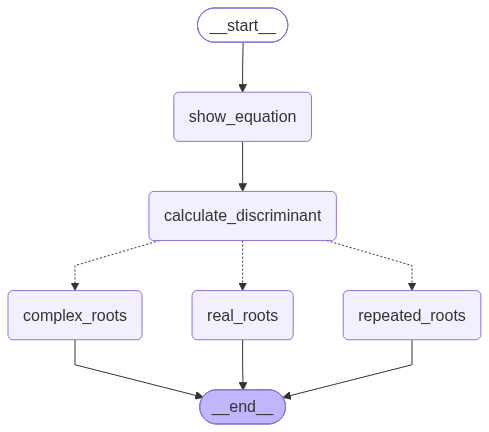

In [10]:
workflow

In [11]:
intitial_state={
    "a":8,
    "b":-5,
    "c":-4
}

workflow.invoke(intitial_state)

{'a': 8, 'b': -5, 'c': -4, 'equation': '8x2-5x-4', 'discriminant': 153}